# MDR-TS v3.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v3.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

Added families of features (`A-I`). Refer to **README_ALL.md** for details. The goal is to evaluate each family's contribution to model performance, then pick them apart one by one (starting with the worst performers)

Skipped a couple because they are "unstable". See list below:

- **2, A**: Second Difference
- **3, A**: n-Step Difference (general n beyond k=7)
- **6, B**: Moving Average
- **10, B**: Rolling Minimum
- **11, B**: Rolling Maximum
- **12, B**: Rolling Range
- **17, C**: Soil Moisture Memory Index (general SMM beyond API/NDMI/SAR/LST)
- **18, D**: Dominant Fourier Frequency
- **19, D**: Spectral Entropy
- **24, E**: Radar Coherence (Sentinel-1)
- **25, E**: Radar Temporal Roughness Index (RTI, full form)
- **29, F**: SWIR Reflectance Temporal Curve
- **33, H**: Radar–Optical Lag Correlation
- **34, H**: Temperature–Moisture Temporal Coupling


For other info see `MDR-TS-v1.0`

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [ ]:
# Project paths
VERSION = "v3"
SUBVERSION = "v3.2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_all/train_derived_all.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_all/val_derived_all.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_all/test_derived_all.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv
train: dropped columns ['slope', 'elev']

train: shape=(15904, 94)
train: columns=94
val: dropped columns ['slope', 'elev']

val: shape=(3408, 94)
val: columns=94
test: dropped columns ['slope', 'elev']

test: shape=(3408, 94)
test: columns=94


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 94

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_grad_G_API_kobs7', 'A_pct_G_API', 'V_rollstd_G_API_kobs7']


## 4. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'A_d_E_SAR_ratio_kobs1',
    'A_d_F_NDMI_kobs1',
    'A_d_G_API_kobs1',
    'A_d_LST_modis_kobs1',
    'C_smm_E_SAR_ratio_alpha0.85_n5',
    'C_smm_F_NDMI_alpha0.85_n5',
    'C_smm_G_API_alpha0.85_n5',
    'C_smm_LST_modis_alpha0.85_n5',
    'DOY',
    'D_sa_E_SAR_ratio',
    'D_sa_F_NDMI',
    'D_sa_LST_modis',
    'D_z_E_SAR_ratio',
    'D_z_F_NDMI',
    'D_z_LST_modis',
    'E_SAR_diff',
    'E_SAR_ratio',
    'F_MSI',
    'F_NDMI',
    'F_NDVI',
    'G_API',
    'G_DSLR',
    'G_DSLR_isnan',
    'G_rain_sum_30d',
    'G_rain_sum_3d',
    'G_rain_sum_7d',
    'I_ts_spike_s1_vv',
    'LST_modis',
    'V_rollstd_E_SAR_ratio_kobs7',
    'V_rollstd_F_NDMI_kobs7',
    'V_rollstd_G_API_kobs7',
    'V_rollstd_LST_modis_kobs7',
    'aspect',
    'precip_mm',
    's1_vh',
    's1_vv',
    's2_b11',
    's2_b12',
    's2_b4',
    's2_b8'
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 40
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[OK] station Touchet_WA_824: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-17 00:00:00
    val   min date: 2021-08-18 00:00:00
  Station Quinault:
    train max date: 2021-09-03 00:00:00
    val   min date: 2021-09-04 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-05-13 00:00:00
    val   min date: 2021-05-14 00:00:00
  Station Spokane:
    train max date: 2021-09-19 00:00:00
    val   min date: 2021-09-20 00:00:00
  Station Touchet_WA_824:
    train max date: 2018-06-07 00:00:00
    val   min date: 2018-06-08 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-19 00:00:00

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 00:00:00 -- 2023-12-29 00:00:00

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (15904, 40)
  X_val:   (3408, 40)
  X_test:  (3408, 40)
  y_train: (15904,)


### 6.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
C_smm_G_API_alpha0.85_n5,1.398499e+02,160.921738,0.000000,1168.583344
G_rain_sum_30d,1.338338e+02,149.349569,0.000000,1100.500000
DOY,1.850239e+02,103.325581,1.000000,366.000000
G_API,4.437373e+01,51.814489,0.000000,408.757381
G_rain_sum_7d,3.523672e+01,49.781450,0.000000,477.000000
I_ts_spike_s1_vv,4.028188e+01,44.108631,0.000000,236.000000
C_smm_LST_modis_alpha0.85_n5,9.056506e+02,42.208171,0.000000,997.283054
G_rain_sum_3d,1.770443e+01,28.967554,0.000000,259.400000
aspect,1.643586e+02,13.975917,142.090762,183.089635
LST_modis,2.875445e+02,11.502918,248.913937,316.363128


### 6.3 Feature Correlation

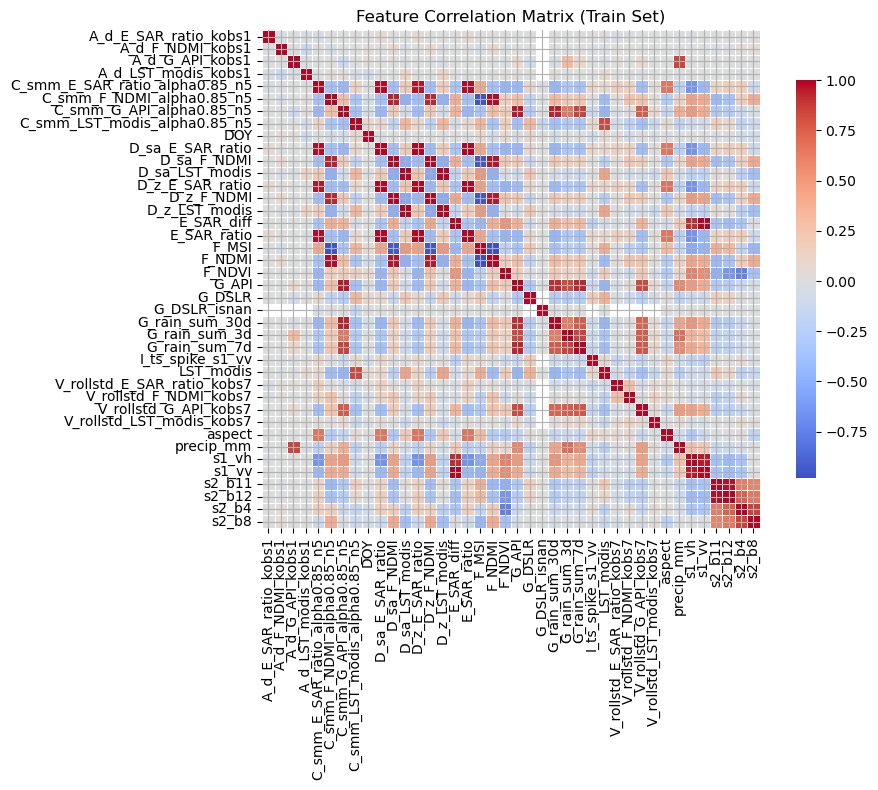

In [12]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [13]:
MODEL_CONFIG = {
    "n_estimators": 500,          # upper bound, early stopping will cap it
    "max_depth": 5, # can try 6 with stronger regularization
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

print("MODEL_CONFIG:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

MODEL_CONFIG:
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [14]:
model = XGBRegressor(**MODEL_CONFIG)
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


## 7. Training Loop

### 7.1 Fit Model

In [15]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print("Training complete")

[0]	validation_0-rmse:0.09807	validation_1-rmse:0.10365
[50]	validation_0-rmse:0.03543	validation_1-rmse:0.05134
[100]	validation_0-rmse:0.02937	validation_1-rmse:0.05083
[150]	validation_0-rmse:0.02708	validation_1-rmse:0.05104
[200]	validation_0-rmse:0.02518	validation_1-rmse:0.05088
[250]	validation_0-rmse:0.02354	validation_1-rmse:0.05097
[300]	validation_0-rmse:0.02212	validation_1-rmse:0.05107
[350]	validation_0-rmse:0.02089	validation_1-rmse:0.05123
[400]	validation_0-rmse:0.01979	validation_1-rmse:0.05118
[450]	validation_0-rmse:0.01878	validation_1-rmse:0.05134
[499]	validation_0-rmse:0.01793	validation_1-rmse:0.05128
Training complete


### 7.2 Predictions

In [16]:
yhat_train = model.predict(X_train)
yhat_val   = model.predict(X_val)
yhat_test  = model.predict(X_test)

print("Predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

Predictions generated
  yhat_train: (15904,)
  yhat_val:   (3408,)
  yhat_test:  (3408,)


### 7.3 Metrics

In [17]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

results = pd.DataFrame([
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
])

results

,split,MAE,RMSE,R2
0,train,0.012754,0.017935,0.968981
1,val,0.039758,0.051282,0.772138
2,test,0.043800,0.056701,0.628125


### 7.4 Diagnostics

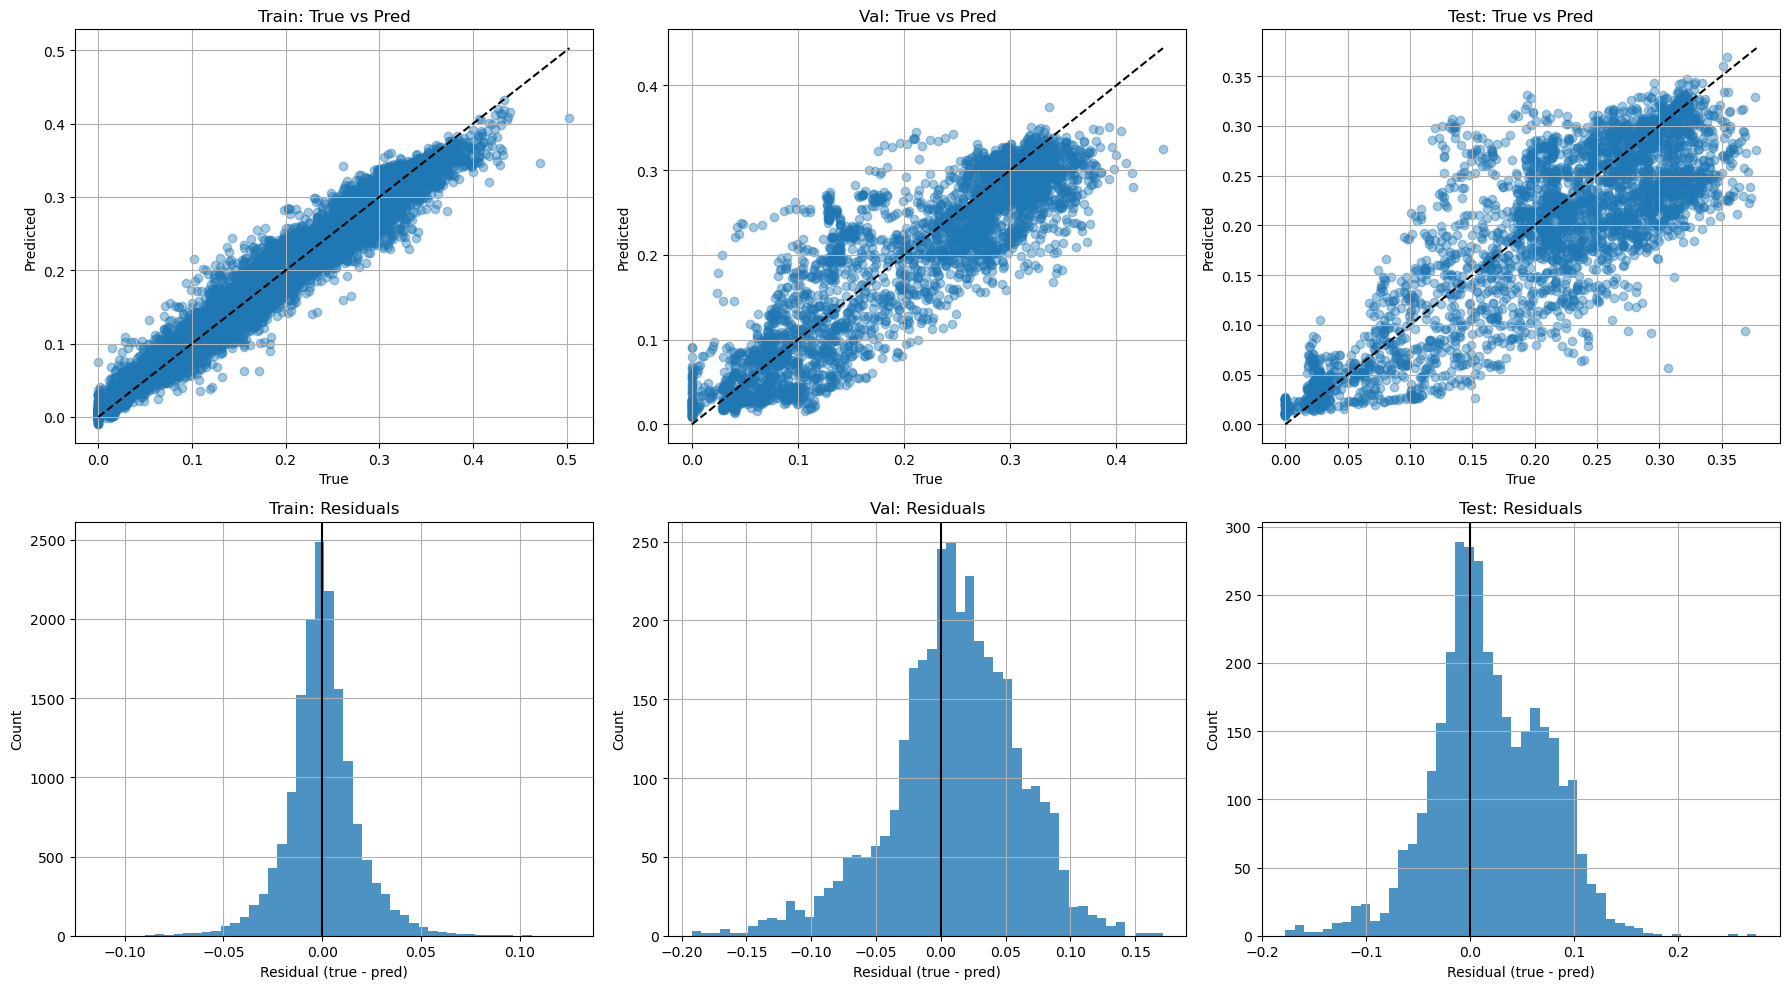

In [18]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

### 7.5 Feature Importance

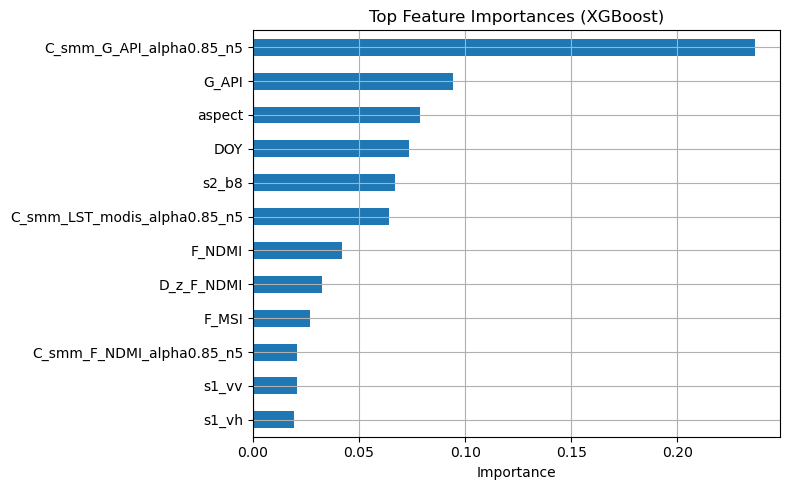

C_smm_G_API_alpha0.85_n5          0.236577
G_API                             0.094197
aspect                            0.078826
DOY                               0.073454
s2_b8                             0.067057
C_smm_LST_modis_alpha0.85_n5      0.064248
F_NDMI                            0.041960
D_z_F_NDMI                        0.032404
F_MSI                             0.026942
C_smm_F_NDMI_alpha0.85_n5         0.020580
s1_vv                             0.020543
s1_vh                             0.019296
E_SAR_ratio                       0.017737
G_rain_sum_30d                    0.017049
G_rain_sum_3d                     0.016414
E_SAR_diff                        0.015968
D_sa_E_SAR_ratio                  0.014530
D_z_E_SAR_ratio                   0.014385
precip_mm                         0.013855
D_sa_F_NDMI                       0.010301
LST_modis                         0.009882
s2_b11                            0.009103
F_NDVI                            0.008977
s2_b12     

In [19]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [20]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.0438,0.056701,0.628125,3408


### 8.2 Test Prediction Scatter

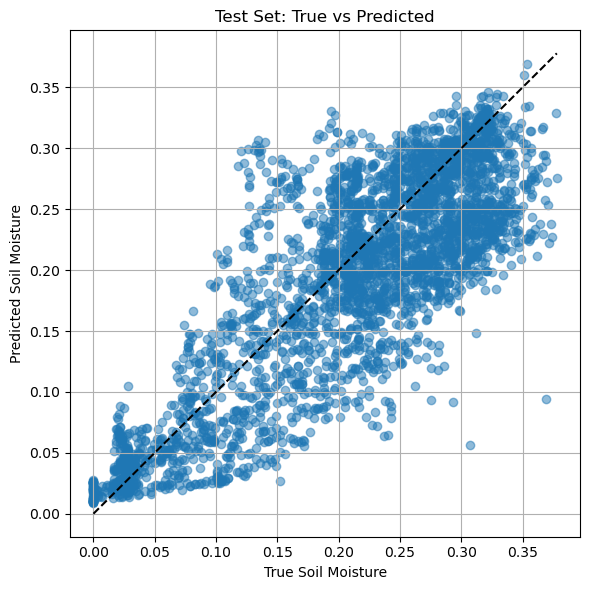

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [22]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val.min()): .6f} to {float(yhat_val.max()): .6f}
TEST range : {float(yhat_test.min()): .6f} to {float(yhat_test.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.010579
TEST residual mean :  0.018095

Prediction ranges
-----------------
VAL  range :  0.009242 to  0.374454
TEST range :  0.008852 to  0.369287



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [23]:
results_idx = results.set_index("split")

gap = {
    "train -> val (MAE)": float(results_idx.loc["val", "MAE"] - results_idx.loc["train", "MAE"]),
    "val -> test (MAE)":  float(results_idx.loc["test", "MAE"] - results_idx.loc["val", "MAE"]),
}
pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.027004
val -> test (MAE),0.004043


### 9.2 Feature Importance Recap

In [24]:
importances.head(10)

C_smm_G_API_alpha0.85_n5        0.236577
G_API                           0.094197
aspect                          0.078826
DOY                             0.073454
s2_b8                           0.067057
C_smm_LST_modis_alpha0.85_n5    0.064248
F_NDMI                          0.041960
D_z_F_NDMI                      0.032404
F_MSI                           0.026942
C_smm_F_NDMI_alpha0.85_n5       0.020580
dtype: float32

## 10. Save Artifacts

In [25]:
from datetime import datetime

RUN_NAME = "mdr_ts_v3_1"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234


In [26]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/model.json


In [27]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/run_metadata.json


In [28]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/metrics.csv


In [29]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/feature_importance.csv


In [30]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## 11. Notes & Experiments

Train models with one family of features removed at a time to identify which features harm or help

In [31]:
from copy import deepcopy
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FAMILY_PREFIXES = ["F_", "E_", "G_", "A_", "V_", "C_", "D_", "I_"]

BASE_FAMILY_NAME = "B"  # optional bucket for non-prefixed columns

def get_family(col: str) -> str:
    for p in FAMILY_PREFIXES:
        if col.startswith(p):
            return p[:-1]  # "F_" -> "F"
    return BASE_FAMILY_NAME

def build_family_map(feature_cols):
    fam_map = {}
    for c in feature_cols:
        fam = get_family(c)
        fam_map.setdefault(fam, []).append(c)
    return fam_map

In [32]:
def train_and_eval(feature_cols, label, model_config):
    Xtr = train_df[feature_cols]
    Xva = val_df[feature_cols]
    Xte = test_df[feature_cols]

    ytr = train_df[TARGET_COL]
    yva = val_df[TARGET_COL]
    yte = test_df[TARGET_COL]

    m = XGBRegressor(**deepcopy(model_config))
    m.fit(Xtr, ytr, verbose=False)

    p_tr = m.predict(Xtr)
    p_va = m.predict(Xva)
    p_te = m.predict(Xte)

    out = {
        "label": label,
        "n_features": len(feature_cols),

        "train_MAE": float(mean_absolute_error(ytr, p_tr)),
        "train_RMSE": float(np.sqrt(mean_squared_error(ytr, p_tr))),
        "train_R2": float(r2_score(ytr, p_tr)),

        "val_MAE": float(mean_absolute_error(yva, p_va)),
        "val_RMSE": float(np.sqrt(mean_squared_error(yva, p_va))),
        "val_R2": float(r2_score(yva, p_va)),
        "val_bias_mean_resid": float((yva.values - p_va).mean()),

        "test_MAE": float(mean_absolute_error(yte, p_te)),
        "test_RMSE": float(np.sqrt(mean_squared_error(yte, p_te))),
        "test_R2": float(r2_score(yte, p_te)),
        "test_bias_mean_resid": float((yte.values - p_te).mean()),
    }
    return out, m

In [33]:
ABLATION_RESULTS = []

# Baseline
base_res, _ = train_and_eval(FEATURE_COLS, "BASELINE", MODEL_CONFIG)
ABLATION_RESULTS.append(base_res)

fam_map = build_family_map(FEATURE_COLS)
families = sorted(fam_map.keys())

print("Families found:", {k: len(v) for k, v in fam_map.items()})

for fam in families:
    drop_cols = set(fam_map[fam])
    cols = [c for c in FEATURE_COLS if c not in drop_cols]
    res, _ = train_and_eval(cols, f"DROP_FAMILY_{fam}", MODEL_CONFIG)
    res["dropped_family"] = fam
    res["dropped_n"] = len(drop_cols)
    ABLATION_RESULTS.append(res)

ablation_df = pd.DataFrame(ABLATION_RESULTS)

Families found: {'A': 4, 'C': 4, 'B': 10, 'D': 6, 'E': 2, 'F': 3, 'G': 6, 'I': 1, 'V': 4}


In [34]:
metrics = [
    "val_MAE", "test_MAE",
    "val_RMSE", "test_RMSE",
    "val_R2", "test_R2",
    "val_bias_mean_resid", "test_bias_mean_resid",
]

for col in metrics:
    ablation_df[f"delta_{col}"] = ablation_df[col] - base_res[col]

# Sort by best test MAE improvement (more negative is better)
ablation_df_sorted = ablation_df.sort_values("delta_test_MAE", ascending=True).reset_index(drop=True)

ablation_df_sorted[[
    "label", "dropped_family", "dropped_n", "n_features",
    "val_MAE", "delta_val_MAE",
    "test_MAE", "delta_test_MAE",
    "test_R2", "delta_test_R2",
    "test_bias_mean_resid", "delta_test_bias_mean_resid"
]]

,label,dropped_family,dropped_n,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,DROP_FAMILY_C,C,4.0,36,0.038873,-0.000885,0.043149,-0.000651,0.637605,0.009479,0.017733,-0.000361
1,DROP_FAMILY_D,D,6.0,34,0.038006,-0.001752,0.043174,-0.000627,0.630746,0.002620,0.018882,0.000787
2,DROP_FAMILY_E,E,2.0,38,0.039400,-0.000358,0.043652,-0.000149,0.632260,0.004135,0.017513,-0.000582
3,BASELINE,NaN,NaN,40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
4,DROP_FAMILY_V,V,4.0,36,0.039290,-0.000467,0.043825,0.000025,0.631496,0.003371,0.017601,-0.000494
5,DROP_FAMILY_G,G,6.0,34,0.039590,-0.000167,0.043888,0.000087,0.623371,-0.004755,0.019500,0.001406
6,DROP_FAMILY_F,F,3.0,37,0.039813,0.000055,0.043941,0.000140,0.631429,0.003304,0.018359,0.000264
7,DROP_FAMILY_A,A,4.0,36,0.039673,-0.000085,0.043977,0.000177,0.628895,0.000769,0.018056,-0.000038
8,DROP_FAMILY_I,I,1.0,39,0.039448,-0.000310,0.044197,0.000396,0.624006,-0.004119,0.018102,0.000007
9,DROP_FAMILY_B,B,10.0,30,0.046260,0.006502,0.047802,0.004002,0.572929,-0.055196,0.024950,0.006855


Ok this is kind of depressing but good at the same time. This means the model is very stable since removing any one family doesn't change much. The next goal here is to start removing individual features that might be redundant within each family and see if that helps. Once I get those, I'll train another model which will serve as the new baseline going forward.

## Redundancy Pruning

In [35]:
import re
from copy import deepcopy
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_eval(feature_cols, label, model_config):
    Xtr = train_df[feature_cols]
    Xva = val_df[feature_cols]
    Xte = test_df[feature_cols]

    ytr = train_df[TARGET_COL]
    yva = val_df[TARGET_COL]
    yte = test_df[TARGET_COL]

    m = XGBRegressor(**deepcopy(model_config))
    m.fit(Xtr, ytr, verbose=False)

    p_tr = m.predict(Xtr)
    p_va = m.predict(Xva)
    p_te = m.predict(Xte)

    out = {
        "label": label,
        "n_features": len(feature_cols),

        "train_MAE": float(mean_absolute_error(ytr, p_tr)),
        "train_RMSE": float(np.sqrt(mean_squared_error(ytr, p_tr))),
        "train_R2": float(r2_score(ytr, p_tr)),

        "val_MAE": float(mean_absolute_error(yva, p_va)),
        "val_RMSE": float(np.sqrt(mean_squared_error(yva, p_va))),
        "val_R2": float(r2_score(yva, p_va)),
        "val_bias_mean_resid": float((yva.values - p_va).mean()),

        "test_MAE": float(mean_absolute_error(yte, p_te)),
        "test_RMSE": float(np.sqrt(mean_squared_error(yte, p_te))),
        "test_R2": float(r2_score(yte, p_te)),
        "test_bias_mean_resid": float((yte.values - p_te).mean()),
    }
    return out, m

def drop_by_prefixes(cols, prefixes):
    prefixes = tuple(prefixes)
    return [c for c in cols if not c.startswith(prefixes)]

def drop_by_regex(cols, patterns):
    pats = [re.compile(p) for p in patterns]
    out = []
    for c in cols:
        if any(p.search(c) for p in pats):
            continue
        out.append(c)
    return out

def keep_by_regex(cols, patterns):
    pats = [re.compile(p) for p in patterns]
    out = []
    for c in cols:
        if any(p.search(c) for p in pats):
            out.append(c)
    return out

def add_deltas(df, base_row):
    metrics = [
        "val_MAE", "test_MAE",
        "val_RMSE", "test_RMSE",
        "val_R2", "test_R2",
        "val_bias_mean_resid", "test_bias_mean_resid",
    ]
    for col in metrics:
        df[f"delta_{col}"] = df[col] - base_row[col]
    return df

In [36]:
ABL = []

base_res, _ = train_and_eval(FEATURE_COLS, "BASELINE", MODEL_CONFIG)
ABL.append(base_res)

# drop volatility extremes
cols_drop_V_extremes = drop_by_prefixes(
    FEATURE_COLS,
    prefixes=("V_rollmin_", "V_rollmax_", "V_rollrng_", "V_rollcv_")
)
res, _ = train_and_eval(cols_drop_V_extremes, "DROP_V_EXTREMES(min/max/rng/cv)", MODEL_CONFIG)
ABL.append(res)

# drop percent change everywhere
cols_drop_pct = drop_by_prefixes(FEATURE_COLS, prefixes=("A_pct_",))
res, _ = train_and_eval(cols_drop_pct, "DROP_A_PCT(all)", MODEL_CONFIG)
ABL.append(res)

# drop kobs2 diffs everywhere
cols_drop_dk2 = drop_by_regex(FEATURE_COLS, patterns=[r"^A_d_.*_kobs2$"])
res, _ = train_and_eval(cols_drop_dk2, "DROP_A_D_kobs2(all)", MODEL_CONFIG)
ABL.append(res)

# drop lag_kobs2 everywhere
cols_drop_lag2 = drop_by_regex(FEATURE_COLS, patterns=[r"^C_lag_.*_kobs2$"])
res, _ = train_and_eval(cols_drop_lag2, "DROP_C_LAG_kobs2(all)", MODEL_CONFIG)
ABL.append(res)

# drop SMM everywhere
cols_drop_smm = drop_by_regex(FEATURE_COLS, patterns=[r"^C_smm_"])
res, _ = train_and_eval(cols_drop_smm, "DROP_C_SMM(all)", MODEL_CONFIG)
ABL.append(res)

# drop lags everywhere
cols_drop_lags = drop_by_regex(FEATURE_COLS, patterns=[r"^C_lag_"])
res, _ = train_and_eval(cols_drop_lags, "DROP_C_LAGS(all)", MODEL_CONFIG)
ABL.append(res)

abl_df = pd.DataFrame(ABL)
abl_df = add_deltas(abl_df, base_res)

abl_df.sort_values("delta_test_MAE", ascending=True)[
    ["label", "n_features", "val_MAE", "delta_val_MAE", "test_MAE", "delta_test_MAE", "test_R2", "delta_test_R2", "test_bias_mean_resid", "delta_test_bias_mean_resid"]
].reset_index(drop=True)

,label,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,DROP_C_SMM(all),36,0.038873,-0.000885,0.043149,-0.000651,0.637605,0.009479,0.017733,-0.000361
1,BASELINE,40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
2,DROP_V_EXTREMES(min/max/rng/cv),40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
3,DROP_A_PCT(all),40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
4,DROP_A_D_kobs2(all),40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
5,DROP_C_LAG_kobs2(all),40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000
6,DROP_C_LAGS(all),40,0.039758,0.000000,0.043800,0.000000,0.628125,0.000000,0.018095,0.000000


In [37]:
def build_v32_candidates(base_cols):
    cands = {}

    # Candidate 1:
    #   keep rollstd/ema/rollmean, drop min/max/rng/cv
    cols = drop_by_prefixes(base_cols, prefixes=("V_rollmin_", "V_rollmax_", "V_rollrng_", "V_rollcv_"))
    cands["v3.2_cand1_keep_V(std,ema,mean)"] = cols

    # Candidate 2:
    #   cand1 + drop A_pct everywhere
    cols2 = drop_by_prefixes(cols, prefixes=("A_pct_",))
    cands["v3.2_cand2_cand1+drop_A_pct"] = cols2

    # Candidate 3:
    #   cand2 + drop all A_d_*_kobs2
    cols3 = drop_by_regex(cols2, patterns=[r"^A_d_.*_kobs2$"])
    cands["v3.2_cand3_cand2+drop_A_d_kobs2"] = cols3

    # Candidate 4a:
    #   cand3 + keep only lags (drop SMM)
    cols4a = drop_by_regex(cols3, patterns=[r"^C_smm_"])
    cands["v3.2_cand4a_cand3+drop_C_smm"] = cols4a

    # Candidate 4b:
    #   cand3 + keep only SMM (drop lags)
    cols4b = drop_by_regex(cols3, patterns=[r"^C_lag_"])
    cands["v3.2_cand4b_cand3+drop_C_lags"] = cols4b

    # Candidate 5:
    #   cand3 + drop lag_kobs2 only (keep lag1,lag5,SMM)
    cols5 = drop_by_regex(cols3, patterns=[r"^C_lag_.*_kobs2$"])
    cands["v3.2_cand5_cand3+drop_C_lag2"] = cols5

    return cands

candidates = build_v32_candidates(FEATURE_COLS)
{ k: len(v) for k, v in candidates.items() }

{'v3.2_cand1_keep_V(std,ema,mean)': 40,
 'v3.2_cand2_cand1+drop_A_pct': 40,
 'v3.2_cand3_cand2+drop_A_d_kobs2': 40,
 'v3.2_cand4a_cand3+drop_C_smm': 36,
 'v3.2_cand4b_cand3+drop_C_lags': 40,
 'v3.2_cand5_cand3+drop_C_lag2': 40}

In [38]:
FEATURE_COLS_V32 = [
    c for c in FEATURE_COLS
    if not c.startswith("A_pct_")
    and not re.search(r"^C_lag_.*_kobs2$", c)
]

print("Baseline n_features:", len(FEATURE_COLS))
print("v3.2 n_features:", len(FEATURE_COLS_V32))

Baseline n_features: 40
v3.2 n_features: 40


In [39]:
v32_res, _ = train_and_eval(FEATURE_COLS_V32, "V3.2_SAFE_PRUNE(A_pct + C_lag_kobs2)", MODEL_CONFIG)

df = pd.DataFrame([base_res, v32_res])
df = add_deltas(df, base_res)
df[["label","n_features","val_MAE","delta_val_MAE","test_MAE","delta_test_MAE","test_R2","delta_test_R2","test_bias_mean_resid","delta_test_bias_mean_resid"]]

,label,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,BASELINE,40,0.039758,0.0,0.0438,0.0,0.628125,0.0,0.018095,0.0
1,V3.2_SAFE_PRUNE(A_pct + C_lag_kobs2),40,0.039758,0.0,0.0438,0.0,0.628125,0.0,0.018095,0.0


In [40]:
import re

def build_v33_features(feature_cols):
    keep = []

    base_keep = [
        "precip_mm", "s1_vv", "s1_vh",
        "s2_b4", "s2_b8", "s2_b11", "s2_b12",
        "LST_modis",
        "elev", "slope", "aspect", "DOY",
        "F_NDVI", "F_NDMI", "F_MSI",
        "E_SAR_ratio", "E_SAR_diff",
        "I_ts_spike_s1_vv",
        "G_DSLR", "G_DSLR_isnan",
        "G_rain_sum_3d", "G_rain_sum_7d", "G_rain_sum_30d",
        "D_sa_F_NDMI", "D_z_F_NDMI",
        "D_sa_E_SAR_ratio", "D_z_E_SAR_ratio",
        "D_sa_LST_modis", "D_z_LST_modis",
    ]

    keep.extend([c for c in base_keep if c in feature_cols])

    signals = ["G_API", "F_NDMI", "E_SAR_ratio", "LST_modis"]

    for sig in signals:
        for c in feature_cols:
            if (
                c == sig
                or re.match(fr"A_d_{sig}_kobs1$", c)
                or re.match(fr"V_rollstd_{sig}_kobs7$", c)
                or re.match(fr"C_smm_{sig}_.*", c)
            ):
                keep.append(c)

    return sorted(set(keep))

FEATURE_COLS_V33 = build_v33_features(FEATURE_COLS)

print("v3.3 n_features:", len(FEATURE_COLS_V33))
FEATURE_COLS_V33

v3.3 n_features: 40


['A_d_E_SAR_ratio_kobs1',
 'A_d_F_NDMI_kobs1',
 'A_d_G_API_kobs1',
 'A_d_LST_modis_kobs1',
 'C_smm_E_SAR_ratio_alpha0.85_n5',
 'C_smm_F_NDMI_alpha0.85_n5',
 'C_smm_G_API_alpha0.85_n5',
 'C_smm_LST_modis_alpha0.85_n5',
 'DOY',
 'D_sa_E_SAR_ratio',
 'D_sa_F_NDMI',
 'D_sa_LST_modis',
 'D_z_E_SAR_ratio',
 'D_z_F_NDMI',
 'D_z_LST_modis',
 'E_SAR_diff',
 'E_SAR_ratio',
 'F_MSI',
 'F_NDMI',
 'F_NDVI',
 'G_API',
 'G_DSLR',
 'G_DSLR_isnan',
 'G_rain_sum_30d',
 'G_rain_sum_3d',
 'G_rain_sum_7d',
 'I_ts_spike_s1_vv',
 'LST_modis',
 'V_rollstd_E_SAR_ratio_kobs7',
 'V_rollstd_F_NDMI_kobs7',
 'V_rollstd_G_API_kobs7',
 'V_rollstd_LST_modis_kobs7',
 'aspect',
 'precip_mm',
 's1_vh',
 's1_vv',
 's2_b11',
 's2_b12',
 's2_b4',
 's2_b8']

In [41]:
v33_res, _ = train_and_eval(FEATURE_COLS_V33, "V3.3_MINIMAL", MODEL_CONFIG)

df = pd.DataFrame([base_res, v32_res, v33_res])
df = add_deltas(df, base_res)
df[[
    "label","n_features",
    "val_MAE","delta_val_MAE",
    "test_MAE","delta_test_MAE",
    "test_R2","delta_test_R2",
    "test_bias_mean_resid","delta_test_bias_mean_resid"
]]

,label,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,BASELINE,40,0.039758,0.0,0.0438,0.0,0.628125,0.0,0.018095,0.0
1,V3.2_SAFE_PRUNE(A_pct + C_lag_kobs2),40,0.039758,0.0,0.0438,0.0,0.628125,0.0,0.018095,0.0
2,V3.3_MINIMAL,40,0.039758,0.0,0.0438,0.0,0.628125,0.0,0.018095,0.0


---

_Jakob Balkovec_